<p>インポート</p>

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [37]:
import matplotlib_fontja

In [38]:
import pingouin as pg

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [40]:
from itertools import product
from linearmodels.panel import PanelOLS

<p>データの読み取り</p>

In [41]:
#df = pd.read_excel("data/testdata.xlsx", sheet_name="Sheet2")
df = pd.read_csv("data/election_data.csv")
df.head()

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合
0,あきる野市,議員,2013/6/23,21,60.0,35.0,0,0,0.190476,0.333333,0.238095,0.142857,0.523810
1,あきる野市,議員,2017/6/11,21,52.0,39.0,15,6,0.285714,0.238095,0.190476,0.142857,0.571429
2,あきる野市,首長,2015/10/4,1,66.0,66.0,1,0,1.000000,1.000000,0.000000,0.000000,1.000000
3,あきる野市,首長,2019/10/6,1,62.0,62.0,1,0,1.000000,0.000000,0.000000,0.000000,1.000000
4,あさぎり町,議員,2012/4/22,16,59.5,50.0,14,2,0.312500,0.062500,0.000000,0.000000,1.000000


In [42]:
df_statistics = pd.read_csv('data/local_gov_statistics.csv')
df_statistics.head()

,地域コード,年度,15~64歳人口,15~64歳人口(女),15~64歳人口(男),15歳未満人口,15歳未満人口(女),15歳未満人口(男),65歳以上の世帯員のいる核家族世帯数,65歳以上世帯員の単独世帯数,...,離婚件数,非労働力人口,非労働力人口(女),非労働力人口(男),非水洗化人口,飲食店数,高等学校数,高等学校生徒数,高齢単身世帯数(65歳以上の者1人),高齢夫婦のみの世帯数
0,R01100,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9124.0,NaN,NaN,NaN,NaN
1,R01100,2015,1235516.0,645405.0,590111.0,221013.0,108270.0,112743.0,178246.0,NaN,...,NaN,651052.0,435482.0,215570.0,7169.0,NaN,NaN,NaN,104650.0,98660.0
2,R01100,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4096.0,NaN,NaN,NaN,7107.0,8502.0,53.0,44774.0,NaN,NaN
3,R01100,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4003.0,NaN,NaN,NaN,6549.0,NaN,52.0,44201.0,NaN,NaN
4,R01100,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4024.0,NaN,NaN,NaN,6363.0,NaN,52.0,44345.0,NaN,NaN


In [43]:
df_region_code = pd.read_csv('data/region_code_correspondence.csv')
df_region_code.head()

,地域コード,都道府県,市区町村
0,R01100,北海道,札幌市
1,R01202,北海道,函館市
2,R01203,北海道,小樽市
3,R01204,北海道,旭川市
4,R01205,北海道,室蘭市


<p>65歳以上人口のみのdfを作成<p>

In [44]:
abv65_df = df_statistics.loc[:,('地域コード','年度','総人口','65歳以上人口')]

In [45]:
abv65_df['65歳以上人口割合'] = abv65_df['65歳以上人口'] / abv65_df['総人口']

In [46]:
abv65_meandf = abv65_df.groupby('地域コード')['65歳以上人口割合'].mean().reset_index()

In [47]:
abv65_meandf = abv65_meandf.merge(df_region_code, on='地域コード', how='left', validate='one_to_one')

<p>それぞれのdfの結びつけ</p>

In [48]:
merged_df = df.merge(abv65_meandf.drop(columns=['都道府県']), on="市区町村", how="left")

<p>議員データと首長データの分離</p>

In [49]:
merged_df['日付'] = pd.to_datetime(merged_df['日付'], format='%Y/%m/%d')  
merged_df['年'] = merged_df['日付'].dt.year

In [50]:
counciler_df = merged_df[merged_df['種別'] == '議員']
chief_df = merged_df[merged_df['種別'] == '首長']

In [51]:
counciler_df.head()

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,地域コード,65歳以上人口割合,年
0,あきる野市,議員,2013-06-23,21,60.0,35.0,0,0,0.190476,0.333333,0.238095,0.142857,0.523810,R13228,0.289397,2013
1,あきる野市,議員,2017-06-11,21,52.0,39.0,15,6,0.285714,0.238095,0.190476,0.142857,0.571429,R13228,0.289397,2017
4,あさぎり町,議員,2012-04-22,16,59.5,50.0,14,2,0.312500,0.062500,0.000000,0.000000,1.000000,R43514,0.364495,2012
5,あさぎり町,議員,2016-04-24,16,61.0,42.0,13,3,0.125000,0.187500,0.000000,0.000000,1.000000,R43514,0.364495,2016
6,あさぎり町,議員,2020-04-26,14,63.5,53.0,11,3,0.071429,0.428571,0.000000,0.000000,1.000000,R43514,0.364495,2020


<p>可視化<p>
<ul>
<li>それぞれのヒストグラム</li>
<li>新人割合と65歳以上の議員割合の相関</li>
<li>住んでいる人の65歳以上割合と議員の65歳以上割合の相関</li>
<li>それぞれの都市での議員と首長の時系列的な折れ線グラフ</li>
</ul>


c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

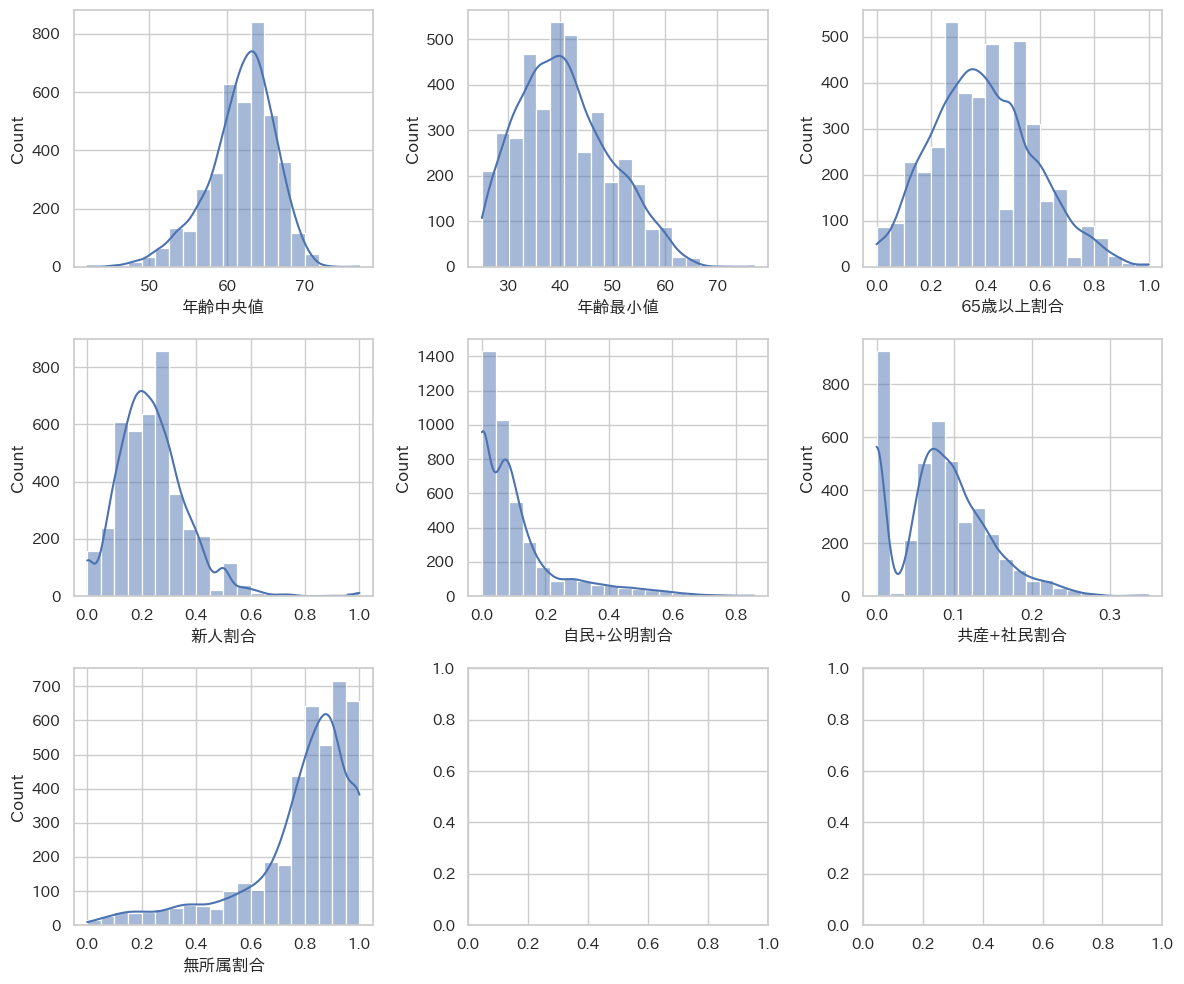

In [52]:
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'IPAexGothic'

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sns.histplot(data=counciler_df, x="年齢中央値", bins=20, kde=True, ax=axes[0, 0])
sns.histplot(data=counciler_df, x="年齢最小値", bins=20, kde=True, ax=axes[0, 1])
sns.histplot(data=counciler_df, x="65歳以上割合", bins=20, kde=True, ax=axes[0, 2])
sns.histplot(data=counciler_df, x="新人割合", bins=20, kde=True, ax=axes[1, 0])
sns.histplot(data=counciler_df, x="自民+公明割合", bins=20, kde=True, ax=axes[1, 1])
sns.histplot(data=counciler_df, x="共産+社民割合", bins=20, kde=True, ax=axes[1, 2])
sns.histplot(data=counciler_df, x="無所属割合", bins=20, kde=True, ax=axes[2,0])

plt.tight_layout()
plt.show()

c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

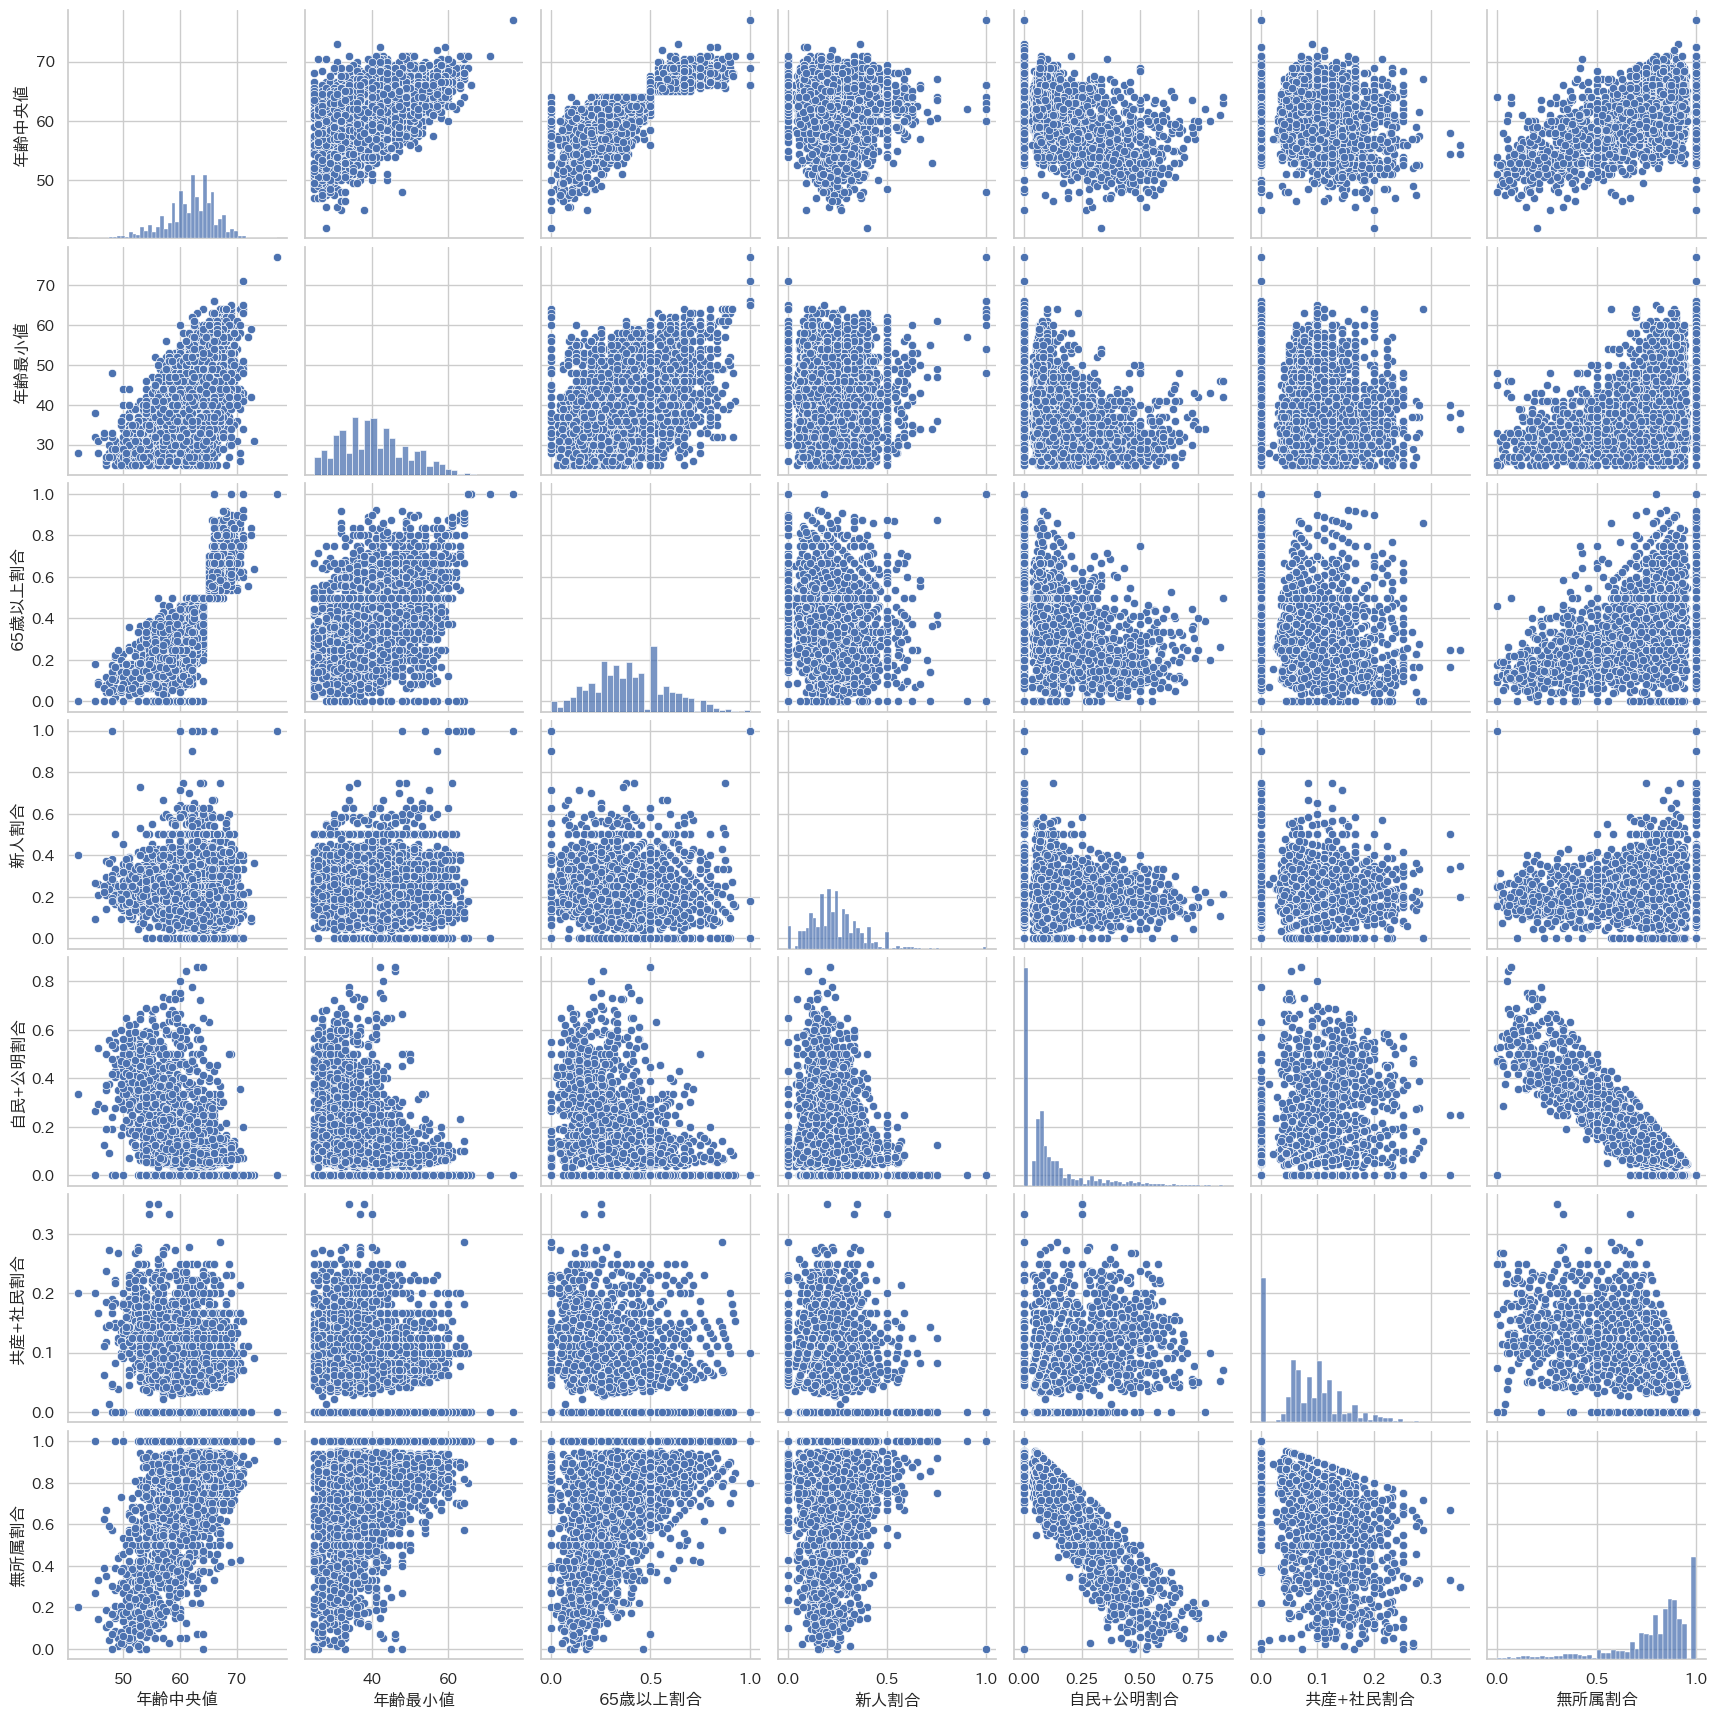

In [53]:
sns.pairplot(counciler_df[["年齢中央値", "年齢最小値", "65歳以上割合", "新人割合", "自民+公明割合", "共産+社民割合", "無所属割合"]])
plt.show()

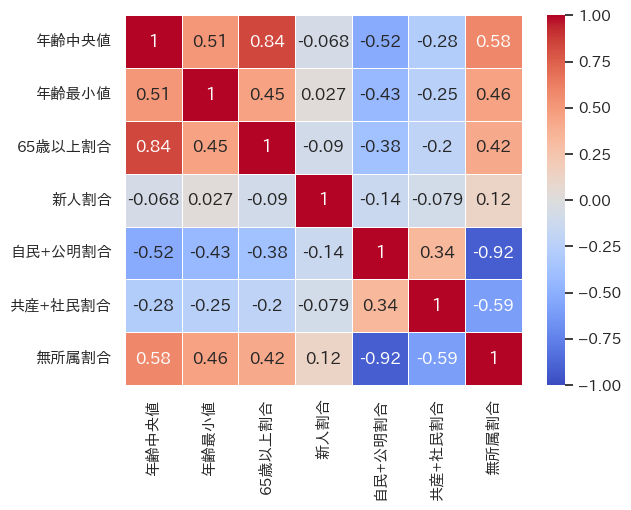

In [54]:
sns.heatmap(counciler_df.loc[:, ['年齢中央値', '年齢最小値', '65歳以上割合', '新人割合', '自民+公明割合', '共産+社民割合', '無所属割合']].corr(), annot=True, cmap='coolwarm',linewidths=0.5, vmin=-1, vmax=1)
plt.show()

In [55]:
partial_corr_matrix = counciler_df.loc[counciler_df['男性'] > 0, ['年齢中央値', '年齢最小値','男性', '65歳以上割合', '新人割合', '自民+公明割合', '共産+社民割合', '無所属割合']].pcorr()

print("偏相関係数行列:")
print(partial_corr_matrix)

偏相関係数行列:
            年齢中央値     年齢最小値        男性   65歳以上割合      新人割合   自民+公明割合   共産+社民割合  \
年齢中央値    1.000000  0.143298 -0.012125  0.763953 -0.062204  0.157893  0.172623   
年齢最小値    0.143298  1.000000 -0.246338  0.066442 -0.002937 -0.052047 -0.049398   
男性      -0.012125 -0.246338  1.000000 -0.062905 -0.147411  0.072380 -0.042097   
65歳以上割合  0.763953  0.066442 -0.062905  1.000000 -0.066202 -0.071571 -0.076521   
新人割合    -0.062204 -0.002937 -0.147411 -0.066202  1.000000 -0.056086 -0.044780   
自民+公明割合  0.157893 -0.052047  0.072380 -0.071571 -0.056086  1.000000 -0.687093   
共産+社民割合  0.172623 -0.049398 -0.042097 -0.076521 -0.044780 -0.687093  1.000000   
無所属割合    0.285795 -0.017721 -0.082266 -0.127278 -0.020340 -0.922956 -0.787846   

            無所属割合  
年齢中央値    0.285795  
年齢最小値   -0.017721  
男性      -0.082266  
65歳以上割合 -0.127278  
新人割合    -0.020340  
自民+公明割合 -0.922956  
共産+社民割合 -0.787846  
無所属割合    1.000000  


In [56]:
def plot_temporal_trajectory(df, x_col, y_col, time_col, group_col, ax=None, title=None):
    """
    時間経過に伴う散布図の推移を矢印で結んで描画する関数

    Parameters:
    -----------
    df : pandas.DataFrame
        描画対象のデータフレーム
    x_col : str
        X軸に指定するカラム名
    y_col : str
        Y軸に指定するカラム名
    time_col : str
        時間経過を表すカラム名（色分けと矢印の順序に使用）
    group_col : str
        各軌跡をグループ化するカラム名（市区町村など。ラベルにも使用）
    ax : matplotlib.axes.Axes, optional
        描画対象のAxes（subplot用）。指定がない場合は現在のAxesを使用。
    title : str, optional
        グラフのタイトル
    """
    # axが指定されていない場合は現在のAxesを取得
    if ax is None:
        ax = plt.gca()

    # 矢印が過去→未来へ向かうように、グループと時間でソート
    df_sorted = df.sort_values(by=[group_col, time_col])

    # 散布図の描画 (引数に ax=ax を指定する)
    sns.scatterplot(
        data=df_sorted, 
        x=x_col, 
        y=y_col, 
        hue=time_col, 
        palette="viridis",
        ax=ax
    )

    # グループ（市区町村など）ごとに矢印とラベルを描画
    for name, group in df_sorted.groupby(group_col):
        xs = group[x_col].values
        ys = group[y_col].values
        
        # 矢印を描画
        for i in range(len(xs) - 1):
            ax.annotate(
                '', 
                xy=(xs[i+1], ys[i+1]), 
                xytext=(xs[i], ys[i]), 
                arrowprops=dict(arrowstyle="->", color="gray", alpha=0.6, lw=1.2)
            )
            
        # 最新の年にラベルを描画
        if len(xs) > 0:
            ax.annotate(
                name, 
                (xs[-1], ys[-1]), 
                fontsize=8, 
                xytext=(3, 3), 
                textcoords="offset points"
            )

    # 軸ラベルとタイトルの設定
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    if title:
        ax.set_title(title)

    # 凡例の調整
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    return ax

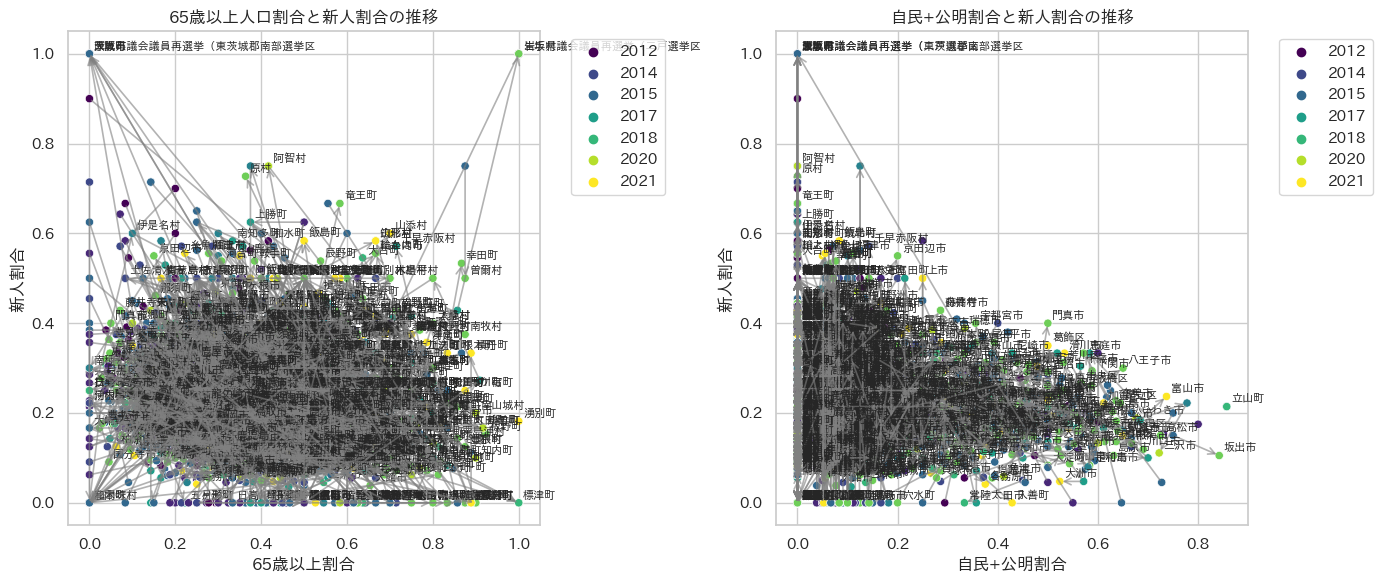

In [ ]:
# 1行2列の図（Figure）と軸（Axes）の配列を作成
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 左側のグラフ (axes[0] に描画) ---
# ※ counciler_df から特定の条件で絞り込んだデータなどを渡します
df_subset_A = counciler_df

plot_temporal_trajectory(
    df=df_subset_A,
    x_col="65歳以上割合",
    y_col="新人割合",
    time_col="年",
    group_col="市区町村",
    ax=axes[0],            # ← ここで左側のエリアを指定
    title="65歳以上人口割合と新人割合の推移"
)

# --- 右側のグラフ (axes[1] に描画) ---
df_subset_B = counciler_df

plot_temporal_trajectory(
    df=df_subset_B,
    x_col="自民+公明割合",
    y_col="新人割合",
    time_col="年",
    group_col="市区町村",
    ax=axes[1],            # ← ここで右側のエリアを指定
    title="自民+公明割合と新人割合の推移"
)

# レイアウトの自動調整（グラフ同士や凡例の重なりを防ぐ）
plt.tight_layout()

# 表示
plt.show()

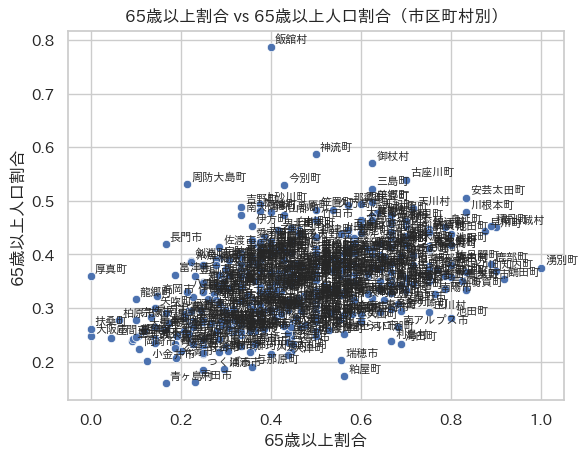

In [58]:
# 散布図
sns.scatterplot(data=counciler_df[counciler_df['年'] > 2019], x="65歳以上割合", y="65歳以上人口割合")

# 各点に市区町村名をラベル表示
for i, row in counciler_df[counciler_df['年'] > 2019].iterrows():
    plt.annotate(row["市区町村"], 
                 (row["65歳以上割合"], row["65歳以上人口割合"]),
                 fontsize=8,       # 文字サイズ
                 xytext=(3,3),     # 文字の位置微調整
                 textcoords="offset points")

plt.xlabel("65歳以上割合")
plt.ylabel("65歳以上人口割合")
plt.title("65歳以上割合 vs 65歳以上人口割合（市区町村別）")
plt.show()

In [59]:
ress = counciler_df["65歳以上割合"].corr(counciler_df["新人割合"])
print(f"65歳以上割合と新人割合の相関係数: {ress:.2f}")

65歳以上割合と新人割合の相関係数: -0.09


In [60]:
# 全体の日付範囲を作る
full_date_range = pd.date_range(start='2011-01-01', end='2023-11-30', freq='D')

# 時系列補完関数（指定日付範囲で前値保持）
def create_city_time_series(df, value_col='年齢中央値', date_range=full_date_range):
    all_ts = pd.DataFrame(index=date_range)
    for city, g in df.groupby('市区町村'):
        g = g.sort_values('日付').set_index('日付')
        ts = g[value_col].reindex(date_range).ffill()  # 前値補完
        all_ts[city] = ts
    return all_ts

# 議員・首長の時系列
counciler_ts = create_city_time_series(counciler_df)
chief_ts = create_city_time_series(chief_df)

counciler_ts = counciler_ts.loc['2015-01-01':,:]
chief_ts = chief_ts.loc['2015-01-01':,:]

# グラフ作成
plt.figure(figsize=(14,7))

# 議員を青系で描画
sns.lineplot(data=counciler_ts, palette="Blues", linewidth=2, legend=True)

# 首長を赤系で描画
sns.lineplot(data=chief_ts, palette="Reds", linewidth=2, legend=True)

plt.xlabel("日付")
plt.ylabel("年齢中央値")
plt.title("市区町村ごとの議員（青）と首長（赤）の年齢中央値時系列")
plt.grid(True)
plt.show()

C:\Users\nshun\AppData\Local\Temp\ipykernel_444\3001302842.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_ts[city] = ts
C:\Users\nshun\AppData\Local\Temp\ipykernel_444\3001302842.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_ts[city] = ts
C:\Users\nshun\AppData\Local\Temp\ipykernel_444\3001302842.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) 

ValueError: cannot reindex on an axis with duplicate labels

<p>欠損値の埋め合わせ</p>
<p>-男女のデータの埋め合わせが必須</p>

In [61]:
zero_mask = (counciler_df['男性'] == 0) & (counciler_df['女性'] == 0)

def fill_male_female(group):
    group = group.sort_values('日付').copy()
    group['男性'] = group['男性'].replace(0, np.nan).ffill().bfill()
    group['女性'] = group['女性'].replace(0, np.nan).ffill().bfill()
    return group

counciler_df = counciler_df.groupby('市区町村', group_keys=False).apply(fill_male_female)

C:\Users\nshun\AppData\Local\Temp\ipykernel_444\1637797231.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  counciler_df = counciler_df.groupby('市区町村', group_keys=False).apply(fill_male_female)


In [62]:
counciler_df['男女比率'] = counciler_df['女性'] / (counciler_df['女性'] + counciler_df['男性'])

In [63]:
counciler_df.head()

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,地域コード,65歳以上人口割合,年,男女比率
0,あきる野市,議員,2013-06-23,21,60.0,35.0,15.0,6.0,0.190476,0.333333,0.238095,0.142857,0.523810,R13228,0.289397,2013,0.285714
1,あきる野市,議員,2017-06-11,21,52.0,39.0,15.0,6.0,0.285714,0.238095,0.190476,0.142857,0.571429,R13228,0.289397,2017,0.285714
4,あさぎり町,議員,2012-04-22,16,59.5,50.0,14.0,2.0,0.312500,0.062500,0.000000,0.000000,1.000000,R43514,0.364495,2012,0.125000
5,あさぎり町,議員,2016-04-24,16,61.0,42.0,13.0,3.0,0.125000,0.187500,0.000000,0.000000,1.000000,R43514,0.364495,2016,0.187500
6,あさぎり町,議員,2020-04-26,14,63.5,53.0,11.0,3.0,0.071429,0.428571,0.000000,0.000000,1.000000,R43514,0.364495,2020,0.214286


In [64]:
chief_df.head()

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,地域コード,65歳以上人口割合,年
2,あきる野市,首長,2015-10-04,1,66.0,66.0,1,0,1.0,1.0,0.0,0.0,1.0,R13228,0.289397,2015
3,あきる野市,首長,2019-10-06,1,62.0,62.0,1,0,1.0,0.0,0.0,0.0,1.0,R13228,0.289397,2019
7,あさぎり町,首長,2015-04-26,1,67.0,67.0,1,0,0.0,1.0,0.0,0.0,1.0,R43514,0.364495,2015
8,あさぎり町,首長,2019-04-21,1,69.0,69.0,1,0,1.0,1.0,0.0,0.0,1.0,R43514,0.364495,2019
11,あま市,首長,2014-04-13,1,51.0,51.0,1,0,0.0,0.0,0.0,0.0,1.0,R23237,0.260814,2014


In [65]:
counciler_df.describe()

,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,65歳以上人口割合,年,男女比率
count,4091,4091.000000,4057.000000,4057.000000,3964.000000,3552.000000,4091.000000,4091.000000,4091.000000,4091.000000,4091.000000,4043.000000,4091.000000,3552.000000
mean,2017-01-27 22:59:06.321193216,17.323393,61.820311,40.736258,14.877901,2.698198,0.238497,0.391456,0.108284,0.081577,0.782869,0.334905,2016.653141,0.144275
min,2012-01-22 00:00:00,1.000000,42.000000,25.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.102715,2012.000000,0.030303
25%,2015-04-26 00:00:00,12.000000,59.500000,34.000000,10.000000,1.000000,0.153846,0.250000,0.000000,0.045455,0.722222,0.278919,2015.000000,0.083333
50%,2017-03-19 00:00:00,16.000000,62.500000,40.000000,13.000000,2.000000,0.222222,0.375000,0.071429,0.083333,0.833333,0.332719,2017.000000,0.125000
75%,2019-04-21 00:00:00,20.000000,65.000000,47.000000,17.250000,3.000000,0.300000,0.500000,0.136364,0.117647,0.916667,0.382862,2019.000000,0.187500
max,2021-12-19 00:00:00,81.000000,77.000000,77.000000,71.000000,22.000000,1.000000,1.000000,0.857143,0.350000,1.000000,0.786419,2021.000000,0.950000
std,NaN,8.685192,4.317383,8.802425,6.985239,2.378354,0.128562,0.187100,0.138070,0.060372,0.208197,0.076425,2.562224,0.083792


In [68]:
counciler_df.loc[counciler_df['男性'] == 71,:]

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,地域コード,65歳以上人口割合,年,男女比率
2718,不明,議員,2019-04-07,74,49.5,27.0,71.0,3.0,0.175676,0.054054,0.283784,0.0,0.027027,NaN,NaN,2019,0.040541


In [ ]:
chief_df.describe()

,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,65歳以上人口割合,年
count,34.0,34.000000,34.000000,34.0,34.0,34.000000,34.000000,34.000000,34.0,34.000000,31.000000,34.000000
mean,1.0,59.764706,59.764706,1.0,0.0,0.411765,0.294118,0.088235,0.0,0.911765,0.353626,2017.852941
std,0.0,8.120527,8.120527,0.0,0.0,0.499554,0.462497,0.287902,0.0,0.287902,0.081984,3.500064
min,1.0,37.000000,37.000000,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.244426,2012.000000
25%,1.0,55.000000,55.000000,1.0,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.280777,2015.000000
50%,1.0,61.500000,61.500000,1.0,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.334257,2018.000000
75%,1.0,65.750000,65.750000,1.0,0.0,1.000000,1.000000,0.000000,0.0,1.000000,0.403372,2020.750000
max,1.0,72.000000,72.000000,1.0,0.0,1.000000,1.000000,1.000000,0.0,1.000000,0.511684,2024.000000


主成分分析以外の手法にもトライして頑健性を確かめたい

<p>主成分分析による次元削減<p>

<ol>
<li>データの形成</li>
<li>標準化</li>
<li>主成分分析</li>
<li>可視化</li>
</ol>

<p>1</p>

<p>議会</p>

In [ ]:
counciler_df['65pp'] = counciler_df['65歳以上割合'] - counciler_df['65歳以上人口割合']

In [ ]:
#pca_df = counciler_df[['年齢最小値','65pp', '新人割合', '男女比率','自民+公明割合','共産+社民割合','無所属割合']].dropna()
pca_df = counciler_df[['65pp', '新人割合', '男女比率','自民+公明割合','共産+社民割合','無所属割合']].dropna()

In [ ]:
pca_df.head(6)

,65pp,新人割合,男女比率,自民+公明割合,共産+社民割合,無所属割合
0,0.012844,0.187500,0.250000,0.187500,0.187500,0.625000
1,0.200344,0.062500,0.250000,0.187500,0.187500,0.625000
2,0.200344,0.214286,0.214286,0.285714,0.214286,0.500000
6,-0.253479,0.222222,0.166667,0.055556,0.000000,0.944444
7,0.024299,0.111111,0.111111,0.055556,0.000000,0.944444
8,0.142355,0.187500,0.062500,0.062500,0.000000,0.937500


<p>首長</p>

In [ ]:
pca_df_cheif = chief_df[['年齢最小値','新人割合', '男性','自民+公明割合','共産+社民割合','無所属割合']].dropna()

In [ ]:
pca_df_cheif.head(5)

,年齢最小値,新人割合,男性,自民+公明割合,共産+社民割合,無所属割合
3,61,1.0,1,0.0,0.0,1.0
4,65,0.0,1,0.0,0.0,1.0
5,69,0.0,1,0.0,0.0,1.0
9,68,0.0,1,0.0,0.0,1.0
10,72,0.0,1,0.0,0.0,1.0


<p>2</p>

<p>議員</p>

In [ ]:
scaler = StandardScaler()
scaler.fit(pca_df)

,copy,True
,with_mean,True
,with_std,True


In [ ]:
pca_df_std = scaler.transform(pca_df)

<p>首長</p>

In [ ]:
scaler_ch = StandardScaler()
scaler_ch.fit(pca_df_cheif)

,copy,True
,with_mean,True
,with_std,True


In [ ]:
pca_df_cheif_std = scaler_ch.transform(pca_df_cheif)

In [ ]:
pca_df_std.describe()

NameError: name 'pca_df_std' is not defined

<p>3</p>

<p>議員</p>

In [ ]:
pca = PCA(n_components=2)
pca.fit(pca_df_std)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [ ]:
pca_fitted = pca.transform(pca_df_std)

In [ ]:
# A. 寄与率（Explained Variance Ratio）
# 各主成分がデータ全体の情報をどれだけ持っているか
ev_ratio = pca.explained_variance_ratio_
cum_ev_ratio = np.cumsum(ev_ratio)

print("【議員ー寄与率】")
for i, ratio in enumerate(ev_ratio):
    print(f"第{i+1}主成分: {ratio:.2%}")
print(f"累積寄与率: {cum_ev_ratio[-1]:.2%}\n")

# B. 主成分負荷量（Loadings）
# 各変数が主成分（軸）に与えている影響力
# pca.components_ は (主成分数, 変数数) の形状なので転置してDataFrame化
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("【議員ー主成分負荷量】")
print(loadings)

【議員ー寄与率】
第1主成分: 41.54%
第2主成分: 22.63%
累積寄与率: 64.18%

【議員ー主成分負荷量】
        PC1       PC2
0  0.281787 -0.440315
1 -0.051227  0.807619
2 -0.162703 -0.016272
3 -0.560989 -0.313588
4 -0.449290  0.199254
5  0.612315  0.124777


<p>首長</p>

首長は同じようにはできないので変更が必要

In [ ]:
pca_ch = PCA(n_components=2)
pca_ch.fit(pca_df_cheif_std)
pca_ch_fitted = pca_ch.transform(pca_df_cheif_std)

In [ ]:
ev_ratio_ch = pca_ch.explained_variance_ratio_
cum_ev_ratio_ch = np.cumsum(ev_ratio_ch)

print("【首長ー寄与率】")
for i, ratio in enumerate(ev_ratio_ch):
    print(f"第{i+1}主成分: {ratio:.2%}")
print(f"累積寄与率: {cum_ev_ratio_ch[-1]:.2%}\n")

loadings2 = pd.DataFrame(
    pca_ch.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_ch.n_components_)]
)

print("【首長ー主成分負荷量】")
print(loadings2)

【首長ー寄与率】
第1主成分: 52.70%
第2主成分: 37.32%
累積寄与率: 90.02%

【首長ー主成分負荷量】
        PC1       PC2
0  0.253851  0.669841
1 -0.323846 -0.620897
2 -0.000000  0.000000
3 -0.644470  0.287923
4 -0.000000  0.000000
5  0.644470 -0.287923


<p>4</p>

In [ ]:
pca_results_df = pd.DataFrame(
    pca_fitted, 
    columns=['PC1', 'PC2'], 
    index=pca_df.index
)

pca_results_ch_df = pd.DataFrame(
    pca_ch_fitted,
    columns=['PC1', 'PC2'],
    index=pca_df_cheif.index
)

In [ ]:
pca_results_df['市区町村'] = counciler_df.loc[pca_df.index, '市区町村']
pca_results_df['年度'] = counciler_df.loc[pca_df.index, '日付'].dt.year

pca_results_ch_df['市区町村'] = chief_df.loc[pca_df_cheif.index, '市区町村']
pca_results_ch_df['年度'] = chief_df.loc[pca_df_cheif.index, '日付'].dt.year

In [ ]:
print("--- PCAスコア議員（各自治体の位置） ---")
print(pca_results_df.head())

print('--------------------------------------')

print("--- PCAスコア首長（各自治体の位置） ---")
print(pca_results_ch_df.head())

--- PCAスコア議員（各自治体の位置） ---
        PC1       PC2   市区町村    年度
0 -0.512405 -0.403268    愛川町  2015
1 -0.091361 -1.940616    愛川町  2019
2 -0.807928 -0.890601    愛川町  2023
6  1.443607  0.524310  安芸高田市  2012
7  2.173939 -1.160435  安芸高田市  2016
--------------------------------------
--- PCAスコア首長（各自治体の位置） ---
         PC1       PC2   市区町村    年度
3   0.053097 -0.817823    愛川町  2014
4   0.838039  0.778683    愛川町  2018
5   0.964961  1.113595    愛川町  2022
9   0.933230  1.029867  安芸高田市  2012
10  1.060152  1.364778  安芸高田市  2016


In [ ]:
pca_results_df['期'] = 1
pca_results_ch_df['期'] = 1

In [ ]:
unique_cities = pca_results_df['市区町村'].unique()
combinations = list(product(unique_cities, [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]))
PCA_df_final = pd.DataFrame(combinations, columns=['市区町村', '年度'])

PCA_df_final = PCA_df_final.merge(pca_results_df.rename(columns={'PC1': 'CPC1', 'PC2': 'CPC2'}), on=['市区町村', '年度'], how='left').rename(columns={'期': '期（議員）'})
PCA_df_final = PCA_df_final.merge(pca_results_ch_df.rename(columns={'PC1': 'CHPC1', 'PC2': 'CHPC2'}), on=['市区町村', '年度'], how='left').rename(columns={'期': '期（首長）'})

base = PCA_df_final['期（議員）'].ffill()
group_id = PCA_df_final['期（議員）'].notna().cumsum()
increment = PCA_df_final['期（議員）'].isna().groupby(group_id).cumsum()
PCA_df_final['期（議員）'] = base + increment

base = PCA_df_final['期（首長）'].ffill()
group_id = PCA_df_final['期（首長）'].notna().cumsum()
increment = PCA_df_final['期（首長）'].isna().groupby(group_id).cumsum()
PCA_df_final['期（首長）'] = base + increment


PCA_ffill_df = PCA_df_final.groupby('市区町村')[['CPC1', 'CPC2', 'CHPC1', 'CHPC2']].ffill()


PCA_df_final['CPC1'] = PCA_ffill_df['CPC1']
PCA_df_final['CPC2'] = PCA_ffill_df['CPC2']
PCA_df_final['CHPC1'] = PCA_ffill_df['CHPC1']   
PCA_df_final['CHPC2'] = PCA_ffill_df['CHPC2']

PCA_df_final = PCA_df_final[PCA_df_final['年度'] >= 2015].reset_index(drop=True)

In [ ]:
PCA_df_final.head()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）
0,愛川町,2015,-0.512405,-0.403268,1.0,0.053097,-0.817823,2.0
1,愛川町,2016,-0.512405,-0.403268,2.0,0.053097,-0.817823,3.0
2,愛川町,2017,-0.512405,-0.403268,3.0,0.053097,-0.817823,4.0
3,愛川町,2018,-0.512405,-0.403268,4.0,0.838039,0.778683,1.0
4,愛川町,2019,-0.091361,-1.940616,1.0,0.838039,0.778683,2.0


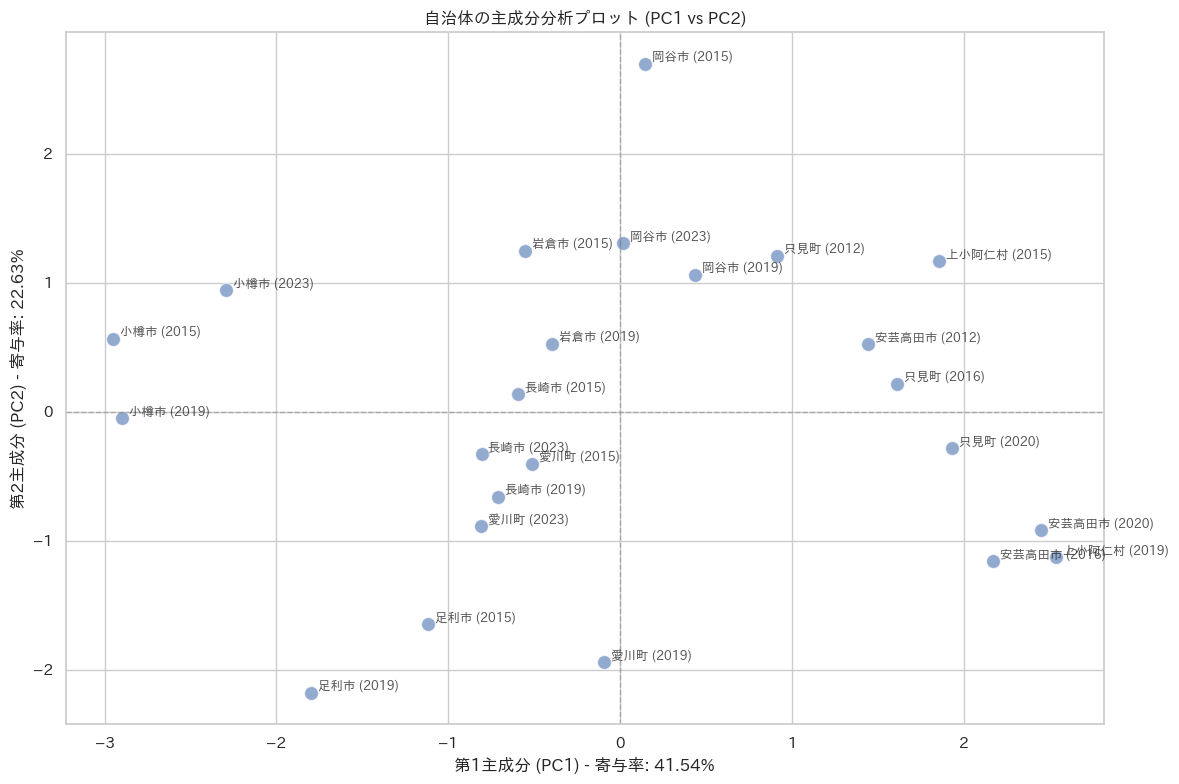

In [ ]:
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

plt.rcParams['font.family'] = 'IPAexGothic'
# 散布図の作成
sns.scatterplot(
    data=pca_results_df, 
    x='PC1', 
    y='PC2', 
    alpha=0.6, 
    s=100
)

# 各点に市区町村名をラベル表示
for i, row in pca_results_df.iterrows():
    plt.annotate(
        row['市区町村'] + " (" + str(row['年度']) + ")", 
        (row['PC1'], row['PC2']),
        fontsize=9, 
        xytext=(5, 2), 
        textcoords='offset points',
        alpha=0.8
    )

# 軸ラベルの設定（寄与率を反映）
plt.xlabel(f"第1主成分 (PC1) - 寄与率: {ev_ratio[0]:.2%}")
plt.ylabel(f"第2主成分 (PC2) - 寄与率: {ev_ratio[1]:.2%}")
plt.title("自治体の主成分分析プロット (PC1 vs PC2)")

# 中心線の描画
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

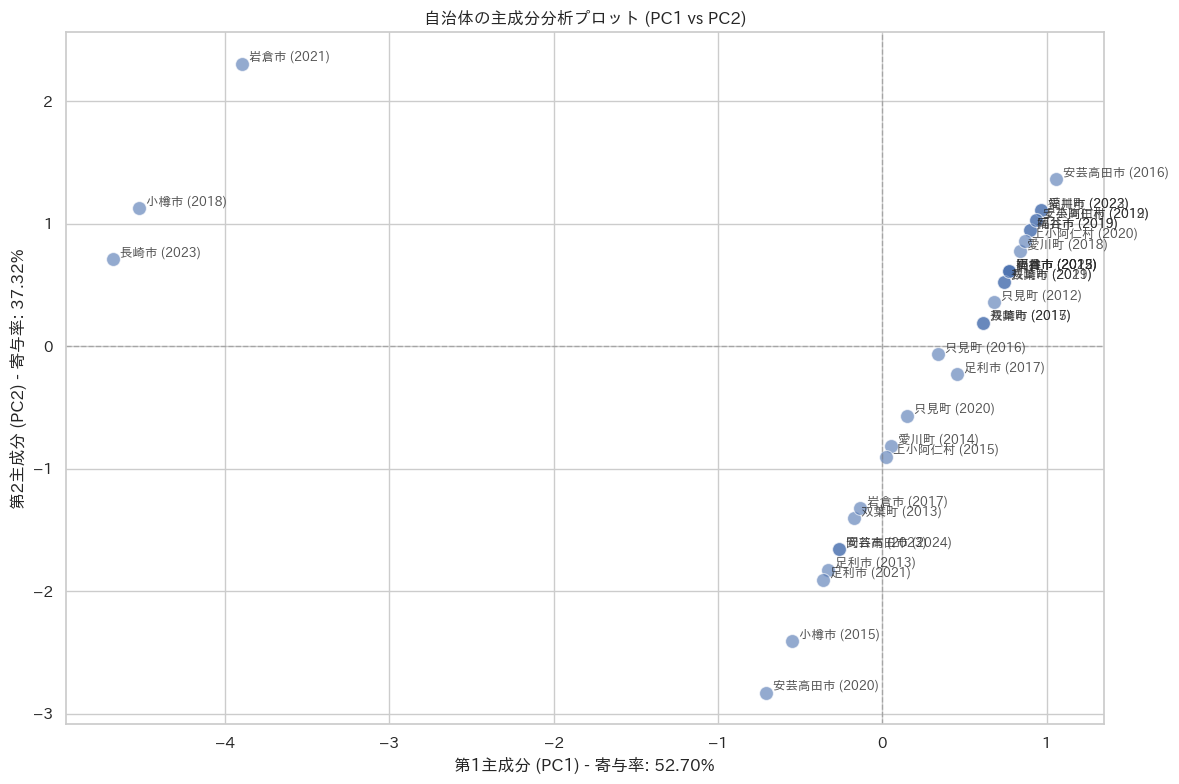

In [ ]:
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

plt.rcParams['font.family'] = 'IPAexGothic'
# 散布図の作成
sns.scatterplot(
    data=pca_results_ch_df, 
    x='PC1', 
    y='PC2', 
    alpha=0.6, 
    s=100
)

# 各点に市区町村名をラベル表示
for i, row in pca_results_ch_df.iterrows():
    plt.annotate(
        row['市区町村'] + " (" + str(row['年度']) + ")", 
        (row['PC1'], row['PC2']),
        fontsize=9, 
        xytext=(5, 2), 
        textcoords='offset points',
        alpha=0.8
    )

# 軸ラベルの設定（寄与率を反映）
plt.xlabel(f"第1主成分 (PC1) - 寄与率: {ev_ratio_ch[0]:.2%}")
plt.ylabel(f"第2主成分 (PC2) - 寄与率: {ev_ratio_ch[1]:.2%}")
plt.title("自治体の主成分分析プロット (PC1 vs PC2)")

# 中心線の描画
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

<p>重回帰分析</p>

問題が山積み

ファイルの取得を異なる方法で行っているため変更が必要

In [ ]:
df_region_code.head()

,地域コード,都道府県,市区町村
0,R01100,北海道,札幌市
1,R01202,北海道,函館市
2,R01203,北海道,小樽市
3,R01204,北海道,旭川市
4,R01205,北海道,室蘭市


In [ ]:
df_final = df_final.sort_values(["地域コード", "年度"])

df_final["世帯数"] = df_final.groupby("地域コード")["世帯数"].transform(
    lambda x: x.interpolate(method="linear")
)

In [ ]:
df_final.tail(10)

,地域コード,年度,市区町村,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
12178,R47381,2019,竹富町,2098.8,1274163.0,6290780.0
12179,R47381,2020,竹富町,2093.0,984224.0,9697688.0
12180,R47381,2021,竹富町,2093.0,942931.0,12205074.0
12181,R47382,2015,与那国町,1080.0,280361.0,5190179.0
12182,R47382,2016,与那国町,1016.0,372401.0,2989124.0
12183,R47382,2017,与那国町,952.0,330900.0,2927390.0
12184,R47382,2018,与那国町,888.0,419102.0,3664604.0
12185,R47382,2019,与那国町,824.0,409718.0,3885404.0
12186,R47382,2020,与那国町,760.0,412816.0,4764744.0
12187,R47382,2021,与那国町,760.0,403181.0,4259031.0


<p>dfの合成</p>

In [ ]:
code_pre_df.head()

,地域コード,都道府県
0,R01100,北海道
1,R01202,北海道
2,R01203,北海道
3,R01204,北海道
4,R01205,北海道


In [ ]:
PCA_df_final.tail()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）
58,上小阿仁村,2017,1.855034,1.164243,3.0,0.021366,-0.901551,3.0
59,上小阿仁村,2018,1.855034,1.164243,4.0,0.021366,-0.901551,4.0
60,上小阿仁村,2019,2.540614,-1.129998,1.0,0.933230,1.029867,1.0
61,上小阿仁村,2020,2.540614,-1.129998,2.0,0.869769,0.862411,1.0
62,上小阿仁村,2021,2.540614,-1.129998,3.0,0.869769,0.862411,2.0


In [ ]:
All_PCA_df = PCA_df_final.copy()

In [ ]:
All_PCA_df.tail()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）
58,上小阿仁村,2017,1.855034,1.164243,3.0,0.021366,-0.901551,3.0
59,上小阿仁村,2018,1.855034,1.164243,4.0,0.021366,-0.901551,4.0
60,上小阿仁村,2019,2.540614,-1.129998,1.0,0.933230,1.029867,1.0
61,上小阿仁村,2020,2.540614,-1.129998,2.0,0.869769,0.862411,1.0
62,上小阿仁村,2021,2.540614,-1.129998,3.0,0.869769,0.862411,2.0


In [ ]:
df_final.tail()

,地域コード,年度,市区町村,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
12183,R47382,2017,与那国町,952.0,330900.0,2927390.0
12184,R47382,2018,与那国町,888.0,419102.0,3664604.0
12185,R47382,2019,与那国町,824.0,409718.0,3885404.0
12186,R47382,2020,与那国町,760.0,412816.0,4764744.0
12187,R47382,2021,与那国町,760.0,403181.0,4259031.0


In [ ]:
All_PCA_df = All_PCA_df.merge(df_final, on=["市区町村", "年度"], how="left")

In [ ]:
All_PCA_df.tail()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）,地域コード,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
58,上小阿仁村,2017,1.855034,1.164243,3.0,0.021366,-0.901551,3.0,R05327,882.8,190853.0,3073260.0
59,上小阿仁村,2018,1.855034,1.164243,4.0,0.021366,-0.901551,4.0,R05327,865.2,186964.0,2427312.0
60,上小阿仁村,2019,2.540614,-1.129998,1.0,0.933230,1.029867,1.0,R05327,847.6,191005.0,2387531.0
61,上小阿仁村,2020,2.540614,-1.129998,2.0,0.869769,0.862411,1.0,R05327,830.0,211568.0,2787409.0
62,上小阿仁村,2021,2.540614,-1.129998,3.0,0.869769,0.862411,2.0,R05327,830.0,206793.0,2850136.0


In [ ]:
All_PCA_df = All_PCA_df.merge(code_pre_df, on="地域コード", how="left")

In [ ]:
All_PCA_df.tail()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）,地域コード,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）,都道府県
58,上小阿仁村,2017,1.855034,1.164243,3.0,0.021366,-0.901551,3.0,R05327,882.8,190853.0,3073260.0,秋田県
59,上小阿仁村,2018,1.855034,1.164243,4.0,0.021366,-0.901551,4.0,R05327,865.2,186964.0,2427312.0,秋田県
60,上小阿仁村,2019,2.540614,-1.129998,1.0,0.933230,1.029867,1.0,R05327,847.6,191005.0,2387531.0,秋田県
61,上小阿仁村,2020,2.540614,-1.129998,2.0,0.869769,0.862411,1.0,R05327,830.0,211568.0,2787409.0,秋田県
62,上小阿仁村,2021,2.540614,-1.129998,3.0,0.869769,0.862411,2.0,R05327,830.0,206793.0,2850136.0,秋田県


In [ ]:
All_PCA_df.isna().sum()

市区町村             0
年度               0
CPC1             0
CPC2             0
期（議員）            0
CHPC1            0
CHPC2            0
期（首長）            0
地域コード            0
世帯数              0
教育費（市町村財政）       0
歳出決算総額（市町村財政）    0
都道府県             0
dtype: int64

In [ ]:
All_PCA_df = All_PCA_df[['市区町村','地域コード','年度','都道府県','CPC1','CPC2','期（議員）','CHPC1','CHPC2','期（首長）','世帯数','教育費（市町村財政）','歳出決算総額（市町村財政）']]
df_OLS = All_PCA_df.copy()

In [ ]:
All_PCA_df.tail()

,市区町村,地域コード,年度,都道府県,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
58,上小阿仁村,R05327,2017,秋田県,1.855034,1.164243,3.0,0.021366,-0.901551,3.0,882.8,190853.0,3073260.0
59,上小阿仁村,R05327,2018,秋田県,1.855034,1.164243,4.0,0.021366,-0.901551,4.0,865.2,186964.0,2427312.0
60,上小阿仁村,R05327,2019,秋田県,2.540614,-1.129998,1.0,0.933230,1.029867,1.0,847.6,191005.0,2387531.0
61,上小阿仁村,R05327,2020,秋田県,2.540614,-1.129998,2.0,0.869769,0.862411,1.0,830.0,211568.0,2787409.0
62,上小阿仁村,R05327,2021,秋田県,2.540614,-1.129998,3.0,0.869769,0.862411,2.0,830.0,206793.0,2850136.0


<p>回帰分析</p>

In [ ]:
#data
df_OLS.tail()

,市区町村,地域コード,年度,都道府県,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
58,上小阿仁村,R05327,2017,秋田県,1.855034,1.164243,3.0,0.021366,-0.901551,3.0,882.8,190853.0,3073260.0
59,上小阿仁村,R05327,2018,秋田県,1.855034,1.164243,4.0,0.021366,-0.901551,4.0,865.2,186964.0,2427312.0
60,上小阿仁村,R05327,2019,秋田県,2.540614,-1.129998,1.0,0.933230,1.029867,1.0,847.6,191005.0,2387531.0
61,上小阿仁村,R05327,2020,秋田県,2.540614,-1.129998,2.0,0.869769,0.862411,1.0,830.0,211568.0,2787409.0
62,上小阿仁村,R05327,2021,秋田県,2.540614,-1.129998,3.0,0.869769,0.862411,2.0,830.0,206793.0,2850136.0


In [ ]:
df_OLS = df_OLS.sort_values(["地域コード", "年度"])

In [ ]:
df_OLS['ln_教育費'] = np.log(df_OLS['教育費（市町村財政）'])
df_OLS['ln_算出決算総額'] = np.log(df_OLS['歳出決算総額（市町村財政）'])
df_OLS['ln_世帯数'] = np.log(df_OLS['世帯数'])

In [ ]:
term_dummies = pd.get_dummies(df_OLS['期（議員）'], prefix='term')

In [ ]:
term_dummies.head()

,term_1.0,term_2.0,term_3.0,term_4.0
21,1,0,0,0
22,0,1,0,0
23,0,0,1,0
24,0,0,0,1
25,1,0,0,0


In [ ]:
pc_cols = ['CPC1', 'CPC2', 'CHPC1', 'CHPC2']
interaction_vars = []

# 1期目をベースラインとして除外し、2〜4期目の交差項をループで一括作成
for pc in pc_cols:
    for s in [2.0, 3.0, 4.0]:
        col_name = f'{pc}_term_{int(s)}'
        df_OLS[col_name] = df_OLS[pc] * term_dummies[f'term_{s}']
        interaction_vars.append(col_name)

In [ ]:
df_panel = df_OLS.set_index(['市区町村', '年度'])

In [ ]:
exog_vars = interaction_vars + ['ln_算出決算総額']

In [ ]:
df_reg = df_panel[['ln_教育費'] + exog_vars].dropna()

In [ ]:
df_reg.tail()

ln_教育費  CPC1_term_2  CPC1_term_3  CPC1_term_4  CPC2_term_2  \
市区町村 年度                                                                    
長崎市  2017  16.340634     -0.00000    -0.591583    -0.000000     0.000000   
     2018  16.476082     -0.00000    -0.000000    -0.591583     0.000000   
     2019  16.679175     -0.00000    -0.000000    -0.000000    -0.000000   
     2020  16.595095     -0.70793    -0.000000    -0.000000    -0.660197   
     2021  16.606525     -0.00000    -0.707930    -0.000000    -0.000000   

           CPC2_term_3  CPC2_term_4  CHPC1_term_2  CHPC1_term_3  CHPC1_term_4  \
市区町村 年度                                                                         
長崎市  2017     0.137078     0.000000      0.000000      0.615925      0.000000   
     2018     0.000000     0.137078      0.000000      0.000000      0.615925   
     2019    -0.000000    -0.000000      0.000000      0.000000      0.000000   
     2020    -0.000000    -0.000000      0.742847      0.000000      0.000000   
     2021    -0.660197    -0.000000      0.000000      0.742847      0.000000   

           CHPC2_term_2  CHPC2_term_3  CHPC2_term_4  ln_算出決算総額  
市区町村 年度                                                         
長崎市  2017      0.000000      0.192587      0.000000  19.132183  
     2018      0.000000      0.000000      0.192587  19.151765  
     2019      0.000000      0.000000      0.000000  19.177846  
     2020      0.527499      0.000000      0.000000  19.433772  
     2021      0.000000      0.527499      0.000000  19.357169

In [ ]:
model = PanelOLS(df_reg['ln_教育費'], df_reg[exog_vars], entity_effects=True, time_effects=True)

<p>モデルは以下のようになっている</p>
<p>市区町村の効果＋時間の効果＋議会主成分１＊（それぞれの時間）＋議会主成分２＊（それぞれーー）＋首長主成分１＊（それぞれの時間）＋首長主成分２＊（それぞれの時間）＋算出決算総額log -> 教育費log</p>

In [ ]:
results = model.fit(cov_type='clustered', cluster_entity=True)

In [ ]:
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_教育費   R-squared:                        0.3325
Estimator:                   PanelOLS   R-squared (Between):              0.8598
No. Observations:                  63   R-squared (Within):               0.4558
Date:                Fri, Apr 10 2026   R-squared (Overall):              0.8598
Time:                        02:22:59   Log-likelihood                    58.477
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.3409
Entities:                           9   P-value                           0.2372
Avg Obs:                       7.0000   Distribution:                   F(13,35)
Min Obs:                       7.0000                                           
Max Obs:                       7.0000   F-statistic (robust):          1.296e+14
                            

In [ ]:
with open("regression_results.txt", "w", encoding="utf-8") as f:
    f.write(results.summary.as_text())

print("結果を regression_results.txt に保存しました！")

結果を regression_results.txt に保存しました！
